#***EXPLORATORY DATA ANALYSIS***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
Netflix_df = pd.read_csv('/content/drive/MyDrive/ML end-to-end project /Unsupervised ML Project/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv', encoding = 'latin1')
Netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
Netflix_df.shape

(7787, 12)

In [ ]:
Netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
Netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
Netflix_df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [ ]:
Netflix_df.duplicated().sum()

np.int64(0)

In [ ]:
Netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

**Feature Selection**

In [ ]:
#Dropping Unwanted features
Netflix_data = Netflix_df.drop(['show_id', 'title', 'director', 'cast'], axis = 1)
Netflix_data.head()

,type,country,date_added,release_year,rating,duration,listed_in,description
0,TV Show,Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,Movie,Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,Movie,Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,Movie,United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,Movie,United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


**Feature Manipulation & Engineering**

In [ ]:
#Modifying date added column
Netflix_data['date_added'] = Netflix_data['date_added'].str.strip()
Netflix_data['date_added'] = pd.to_datetime(Netflix_data['date_added'])
Netflix_data['year_added'] = Netflix_data['date_added'].dt.year
Netflix_data['month_added'] = Netflix_data['date_added'].dt.month

In [ ]:
Netflix_data['duration'] = Netflix_data['duration'].str.strip()
Netflix_data['duration'] = Netflix_data['duration'].str.replace(' min', '')
Netflix_data['duration'] = Netflix_data['duration'].str.replace(' Seasons', '')
Netflix_data['duration'] = Netflix_data['duration'].str.replace(' Season', '')
Netflix_data['duration'] = Netflix_data['duration'].astype(int)

In [ ]:
Netflix_data.head()

,type,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,TV Show,Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0
1,Movie,Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0
2,Movie,Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0
3,Movie,United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0
4,Movie,United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0


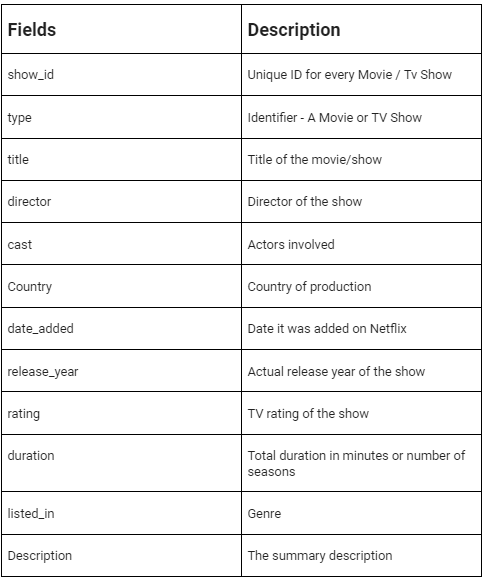

In [ ]:
Netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          7787 non-null   object        
 1   country       7280 non-null   object        
 2   date_added    7777 non-null   datetime64[ns]
 3   release_year  7787 non-null   int64         
 4   rating        7780 non-null   object        
 5   duration      7787 non-null   int64         
 6   listed_in     7787 non-null   object        
 7   description   7787 non-null   object        
 8   year_added    7777 non-null   float64       
 9   month_added   7777 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 608.5+ KB


Goal - To Perform clustering using Netflix Dataset and the aim is to identify patterns or similarities  

Analysis :
1. Movies vs TV Shows (Understanding how many movies & TV shows are present on the Netflix)
2. Country vs Movies/TV Shows here also find count of movies & tv shows for each country
3. Movies/TV Shows vs Release year (Find out how many movies were released in a particular year)
4. Duration vs Movie/TV Shows (Find out the count of movies in a particular duration)
5. Rating vs Movie/TV Shows
6. Duration vs Rating
7. Listed_in(Genre) vs Movie/TV Shows counts
8. Country vs Duration (Finding out average duration according to country)
9. Country vs Listed_in(Genre) ( Find out which countries prefer which genres)
10. Distribution of Duration(Movies) & Distribution of Duration(TV Shows)
11. Listed_in(Genre) Vs Rating
12. Year_added vs Movie & Tv Shows
13. Month_added vs Movie & TV Shows
14. Country vs Rating
This analysis is done for understanding relationship between all the variables

**Visualizations**

##**Univariate Analysis**

 ### Chart 1

In [ ]:
fig = px.histogram(Netflix_data, x = 'type', title = 'Movies vs TV Show Distribution')
fig.update_layout(
    xaxis_title="Type",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##**Bivariate Analysis**

In [ ]:
top_10_countries = Netflix_data['country'].value_counts().head(10).index
df_top = Netflix_data[Netflix_data['country'].isin(top_10_countries)]

fig = px.histogram (
    df_top,
    y ='country',
    color = 'type',
    title='Top 10 Countries with Most Movies & TV Shows',
    category_orders = {"country" : top_10_countries} #ensures descending order
    )
fig.update_layout(
    xaxis_title="Count",
    yaxis_title="Country"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
year_counts = Netflix_data['release_year'].value_counts().sort_index()

fig = px.line(x=year_counts.index, y=year_counts.values,
              labels={'x':'Release Year','y':'Count'},
              title='Content Released Per Year')
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.box(
    Netflix_data,
    x='type',
    y='duration',
    title='Distribution of Duration by Content type',
    )
fig.update_layout(
    xaxis_title="Type",
    yaxis_title="Duration"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram(
    Netflix_data,
    x='rating',
    color='type',
    title='Rating vs Content Type')
fig.update_layout(
    xaxis_title="Rating",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.box(
    Netflix_data,
    x='rating',
    y='duration',
    title='Duration vs Rating')
fig.update_layout(
    xaxis_title="Rating",
    yaxis_title="Duration"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
Netflix_data['main_genre'] = Netflix_data['listed_in'].apply(lambda x: x.split(',')[0])
fig = px.histogram(
    Netflix_data,
    y='main_genre',
    color = 'type',
    title='Genre vs Content Type')

fig.update_layout(
    xaxis_title="Count",
    yaxis_title="Genre",
    height = 800
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
from pandas.core.indexes import category
movies = Netflix_data[Netflix_data['type'] == 'Movie']
top_10_countries_movies = movies['country'].value_counts().head(10).index
movies_top = movies[movies['country'].isin(top_10_countries_movies)]
fig = px.histogram(
    movies_top,
    x='country',
    y='duration',
    title='Average Movie Duration by Country(Top 10)',
    histfunc='avg',
    category_orders = {'country' : top_10_countries_movies}
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Avg of Duration",
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
TV_Shows = Netflix_data[Netflix_data['type'] == 'TV Show']
top_10_countries_tvshows = TV_Shows['country'].value_counts().head(10).index
TV_Shows_top = TV_Shows[TV_Shows['country'].isin(top_10_countries_tvshows)]
fig = px.histogram(
    TV_Shows_top,
    x = 'country',
    y = 'duration',
    title='Average Movie TV Show Duration by Country(Top 10)',
    histfunc='avg',
    category_orders = {'country' : top_10_countries_tvshows}
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Avg of Duration"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram(
    Netflix_data,
    x='main_genre',
    color='rating',
    title='Genre vs Rating')
fig.update_layout(
    xaxis_title="Genre",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
import plotly.figure_factory as ff

data = [movies['duration']]
labels = ['Movie Duration']

fig = ff.create_distplot(
    data,
    labels,
    show_hist=True,
    show_rug=False
)

fig.update_layout(
    title="Movie Duration Distribution with KDE",
    xaxis_title="Duration (minutes)",
    yaxis_title="Density"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
data = [TV_Shows['duration']]
labels = ['TV Show Duration']

fig = ff.create_distplot(
    data,
    labels,
    show_hist=True,
    show_rug=False
)

fig.update_layout(
    title="TV Show Duration Distribution with KDE",
    xaxis_title="Duration (No. of Seasons)",
    yaxis_title="Density"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram(
    Netflix_data,
    x = 'year_added',
    color = 'type',
    title='Year Added vs Content Type')

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Count"
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
Netflix_data.head()

,type,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,main_genre
0,TV Show,Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows
1,Movie,Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas
2,Movie,Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies
3,Movie,United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure
4,Movie,United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,Dramas


In [ ]:
fig = px.histogram(
    Netflix_data,
    x = 'month_added',
    color = 'type',
    title='Month Added vs Content Type')

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Count",
    width = 1000
)

fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
fig = px.histogram (
    df_top,
    x ='country',
    color = 'rating',
    title='Top 10 Countries with distribution of ratings',
    category_orders = {"country" : top_10_countries} #ensures descending order
    )
fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Count"
)
fig.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
Netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          7787 non-null   object        
 1   country       7280 non-null   object        
 2   date_added    7777 non-null   datetime64[ns]
 3   release_year  7787 non-null   int64         
 4   rating        7780 non-null   object        
 5   duration      7787 non-null   int64         
 6   listed_in     7787 non-null   object        
 7   description   7787 non-null   object        
 8   year_added    7777 non-null   float64       
 9   month_added   7777 non-null   float64       
 10  main_genre    7787 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 669.3+ KB


## **Multivariate Analysis**

In [ ]:
corr = Netflix_data[['release_year', 'duration', 'year_added', 'month_added']].corr()

fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index),
    annotation_text=corr.round(2).values,
    colorscale='Viridis'
)

fig.update_layout(title='Correlation Heatmap')
fig.show()


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
Netflix_Clustering = Netflix_data.copy()

In [ ]:
# Handling Missing Values & Missing Value Imputation
Netflix_Clustering.isnull().sum()

,0
type,0
country,507
date_added,10
release_year,0
rating,7
duration,0
listed_in,0
description,0
year_added,10
month_added,10


In [ ]:
Netflix_Clustering['country'].fillna('Unknown', inplace=True)
Netflix_Clustering['rating'].fillna('Not Rated', inplace=True)

/tmp/ipykernel_7684/1206264581.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_7684/1206264581.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

In [ ]:
Netflix_Clustering.dropna(
    subset=['date_added', 'year_added', 'month_added'],
    inplace=True
)

In [ ]:
Netflix_Clustering.drop('date_added', axis = 1, inplace = True)
# We have already extracted information from it in the form of year_added & mobth_added columns so we don't need this feature/column for training our algorithm

In [ ]:
Netflix_Clustering.shape

(7777, 10)

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
Netflix_Clustering['movie_duration']  = Netflix_Clustering.apply(lambda x: x['duration'] if x['type'] == 'Movie' else 0, axis = 1 )
Netflix_Clustering['tv_show_seasons'] = Netflix_Clustering.apply(lambda x: x['duration'] if x['type'] == 'TV Show' else 0, axis = 1)

In [ ]:
Netflix_Clustering.head()

,type,country,release_year,rating,duration,listed_in,description,year_added,month_added,main_genre,movie_duration,tv_show_seasons
0,TV Show,Brazil,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows,0,4
1,Movie,Mexico,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas,93,0
2,Movie,Singapore,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies,78,0
3,Movie,United States,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure,80,0
4,Movie,United States,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,Dramas,123,0


In [ ]:
Netflix_Clustering.drop(['duration'], axis = 1, inplace = True)

In [ ]:
#We are performing this step because, when we applied encoding the feature size was around 774 features, even after applying pca the feature size was 702.
#So we need to select only top 10-15 countries so that feature size will not increase
top_countries = Netflix_Clustering['country'].value_counts().head(15).index
Netflix_Clustering['country'] = Netflix_Clustering['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

In [ ]:
Netflix_Clustering.shape

(7777, 11)

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
Netflix_Clustering['listed_in'] = Netflix_Clustering['listed_in'].apply(lambda x: x.split(','))

In [ ]:
Netflix_Clustering.head()

,type,country,release_year,rating,listed_in,description,year_added,month_added,main_genre,movie_duration,tv_show_seasons
0,TV Show,Brazil,2020,TV-MA,"[International TV Shows, TV Dramas, TV Sci-F...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows,0,4
1,Movie,Mexico,2016,TV-MA,"[Dramas, International Movies]",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas,93,0
2,Movie,Other,2011,R,"[Horror Movies, International Movies]","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies,78,0
3,Movie,United States,2009,PG-13,"[Action & Adventure, Independent Movies, Sci...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure,80,0
4,Movie,United States,2008,PG-13,[Dramas],A brilliant group of students become card-coun...,2020.0,1.0,Dramas,123,0


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_df = pd.DataFrame(
    mlb.fit_transform(Netflix_Clustering['listed_in']),
    columns=mlb.classes_,
    index=Netflix_Clustering.index
)

Netflix_Clustering = pd.concat([Netflix_Clustering, genre_df], axis=1)

In [ ]:
Netflix_Clustering.shape

(7777, 84)

In [ ]:
Netflix_Clustering.head()

,type,country,release_year,rating,listed_in,description,year_added,month_added,main_genre,movie_duration,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
0,TV Show,Brazil,2020,TV-MA,"[International TV Shows, TV Dramas, TV Sci-F...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows,0,...,0,0,0,0,0,0,0,0,0,0
1,Movie,Mexico,2016,TV-MA,"[Dramas, International Movies]",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas,93,...,0,0,0,0,0,0,0,0,0,0
2,Movie,Other,2011,R,"[Horror Movies, International Movies]","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies,78,...,0,0,0,0,0,0,0,0,0,0
3,Movie,United States,2009,PG-13,"[Action & Adventure, Independent Movies, Sci...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure,80,...,0,0,0,0,0,0,0,0,0,0
4,Movie,United States,2008,PG-13,[Dramas],A brilliant group of students become card-coun...,2020.0,1.0,Dramas,123,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
Netflix_Clustering = pd.get_dummies(Netflix_Clustering, columns=['type','country','rating'], drop_first=True)

In [ ]:
Netflix_Clustering.shape

(7777, 111)

In [ ]:
netflix_data  = Netflix_Clustering.copy()

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [ ]:
text_data = Netflix_df.copy()

In [ ]:
text_data.dropna(
    subset=['date_added'],
    inplace=True
)

In [ ]:
text_data.shape

(7777, 12)

In [ ]:
import re
import string
import unicodedata

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
nlp_columns = ['title', 'director', 'cast', 'description']
text_preprocessingdf = text_data[nlp_columns]

In [ ]:
text_preprocessingdf.head()

,title,director,cast,description
0,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",In a future where the elite inhabit an island ...
1,7:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",After a devastating earthquake hits Mexico Cit...
2,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...","When an army recruit is found dead, his fellow..."
3,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...","In a postapocalyptic world, rag-doll robots hi..."
4,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",A brilliant group of students become card-coun...


In [ ]:
text_preprocessingdf.shape

(7777, 4)

In [ ]:
text_preprocessingdf.isnull().sum()

,0
title,0
director,2379
cast,718
description,0


In [ ]:
text_preprocessingdf = text_preprocessingdf.fillna('')

In [ ]:
def fix_mojibake(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except:
        return text

In [ ]:
#Applying encoding to columns to fix errors
for col in text_preprocessingdf.columns:
    text_preprocessingdf[col] = text_preprocessingdf[col].apply(fix_mojibake)

In [ ]:
text_preprocessingdf.head(10)

,title,director,cast,description
0,3%,,"João Miguel, Bianca Comparato, Michel Gomes, R...",In a future where the elite inhabit an island ...
1,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",After a devastating earthquake hits Mexico Cit...
2,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...","When an army recruit is found dead, his fellow..."
3,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...","In a postapocalyptic world, rag-doll robots hi..."
4,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",A brilliant group of students become card-coun...
5,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",A genetics professor experiments with a treatm...
6,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...","After an awful accident, a couple admitted to ..."
7,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",After one of his high school students attacks ...
8,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...","When a doctor goes missing, his psychiatrist w..."
9,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",An architect and his wife move into a castle t...


In [ ]:
#For detecting stopwords like the,to etc
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_description(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)  # remove html tags
    text = re.sub(r'http\S+|www\S+', ' ', text)  # remove urls
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # keep only alphabets
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

In [ ]:
#Applying tokenization, lemmatization on description column
text_preprocessingdf['description_clean'] = text_preprocessingdf['description'].apply(preprocess_description)

#####Preprocessing title column

In [ ]:
def preprocess_title(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)  # keep alphabets and digits
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
text_preprocessingdf['title_clean'] = text_preprocessingdf['title'].apply(preprocess_title)

In [ ]:
text_preprocessingdf[text_preprocessingdf['title'].isin(['3%', '9', '7:19', '23:59', '21'])][['title', 'title_clean']]

,title,title_clean
0,3%,3
1,7:19,7 19
2,23:59,23 59
3,9,9
4,21,21


####Preprocessing director column

In [ ]:
def preprocess_director(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z,\s]', ' ', text)  # keep letters, commas, spaces
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.replace(',', ' ')
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
text_preprocessingdf['director_clean'] = text_preprocessingdf['director'].apply(preprocess_director)

####Preprocessing cast column

In [ ]:
def preprocess_cast(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z,\s]', ' ', text)  # keep letters, commas, spaces
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.replace(',', ' ')
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
text_preprocessingdf['cast_clean'] = text_preprocessingdf['cast'].apply(preprocess_cast)

In [ ]:
text_preprocessingdf[['title', 'title_clean',
                      'director', 'director_clean',
                      'cast', 'cast_clean',
                      'description', 'description_clean']].head(10)

,title,title_clean,director,director_clean,cast,cast_clean,description,description_clean
0,3%,3,,,"João Miguel, Bianca Comparato, Michel Gomes, R...",jo o miguel bianca comparato michel gomes rodo...,In a future where the elite inhabit an island ...,future elite inhabit island paradise far crowd...
1,7:19,7 19,Jorge Michel Grau,jorge michel grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",demi n bichir h ctor bonilla oscar serrano aza...,After a devastating earthquake hits Mexico Cit...,devastating earthquake hit mexico city trapped...
2,23:59,23 59,Gilbert Chan,gilbert chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",tedd chan stella chung henley hii lawrence koh...,"When an army recruit is found dead, his fellow...",army recruit found dead fellow soldier forced ...
3,9,9,Shane Acker,shane acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",elijah wood john c reilly jennifer connelly ch...,"In a postapocalyptic world, rag-doll robots hi...",postapocalyptic world rag doll robot hide fear...
4,21,21,Robert Luketic,robert luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",jim sturgess kevin spacey kate bosworth aaron ...,A brilliant group of students become card-coun...,brilliant group student become card counting e...
5,46,46,Serdar Akar,serdar akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",erdal be ik io lu yasemin allen melis birkan s...,A genetics professor experiments with a treatm...,genetics professor experiment treatment comato...
6,122,122,Yasir Al Yasiri,yasir al yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",amina khalil ahmed dawood tarek lotfy ahmed el...,"After an awful accident, a couple admitted to ...",awful accident couple admitted grisly hospital...
7,187,187,Kevin Reynolds,kevin reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",samuel l jackson john heard kelly rowan clifto...,After one of his high school students attacks ...,one high school student attack dedicated teach...
8,706,706,Shravan Kumar,shravan kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...",divya dutta atul kulkarni mohan agashe anupam ...,"When a doctor goes missing, his psychiatrist w...",doctor go missing psychiatrist wife treat biza...
9,1920,1920,Vikram Bhatt,vikram bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",rajneesh duggal adah sharma indraneil sengupta...,An architect and his wife move into a castle t...,architect wife move castle slated become luxur...


In [ ]:
nlp_clean_df = text_preprocessingdf[[
    'title_clean',
    'director_clean',
    'cast_clean',
    'description_clean'
]].copy()

In [ ]:
nlp_clean_df.head()

,title_clean,director_clean,cast_clean,description_clean
0,3,,jo o miguel bianca comparato michel gomes rodo...,future elite inhabit island paradise far crowd...
1,7 19,jorge michel grau,demi n bichir h ctor bonilla oscar serrano aza...,devastating earthquake hit mexico city trapped...
2,23 59,gilbert chan,tedd chan stella chung henley hii lawrence koh...,army recruit found dead fellow soldier forced ...
3,9,shane acker,elijah wood john c reilly jennifer connelly ch...,postapocalyptic world rag doll robot hide fear...
4,21,robert luketic,jim sturgess kevin spacey kate bosworth aaron ...,brilliant group student become card counting e...


#####Vectorizing text columns

I used TF-IDF for semantically rich text fields like description and title, and CountVectorizer for entity-based fields like cast and director, where the presence of names was more informative than relative term weighting.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [ ]:
description_vectorizer = TfidfVectorizer(
    max_features=1500,
    ngram_range=(1, 2),
    min_df=3
)

description_matrix = description_vectorizer.fit_transform(nlp_clean_df['description_clean'])

In [ ]:
description_matrix.shape

(7777, 1500)

In [ ]:
title_vectorizer = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),
    min_df=2
)

title_matrix = title_vectorizer.fit_transform(nlp_clean_df['title_clean'])
title_matrix.shape

(7777, 300)

In [ ]:
cast_vectorizer = CountVectorizer(
    max_features=500,
    min_df=2
)

cast_matrix = cast_vectorizer.fit_transform(nlp_clean_df['cast_clean'])
cast_matrix.shape

(7777, 500)

In [ ]:
director_vectorizer = CountVectorizer(
    max_features=150,
    min_df=2
)

director_matrix = director_vectorizer.fit_transform(nlp_clean_df['director_clean'])
director_matrix.shape

(7777, 150)

In [ ]:
description_features = description_vectorizer.get_feature_names_out()
description_features[:30]

array(['abandoned', 'ability', 'abuse', 'academy', 'accident',
       'accidentally', 'account', 'accused', 'across', 'act', 'action',
       'activist', 'actor', 'actress', 'adaptation', 'addiction', 'adult',
       'adventure', 'affair', 'africa', 'african', 'african american',
       'aftermath', 'age', 'aged', 'agency', 'agent', 'aging', 'ago',
       'agrees'], dtype=object)

In [ ]:
title_features = title_vectorizer.get_feature_names_out()
title_features[:30]

array(['100', 'about', 'adventure', 'adventures', 'after', 'again', 'age',
       'all', 'all the', 'am', 'america', 'american', 'an', 'and',
       'and the', 'are', 'art', 'at', 'at the', 'aur', 'baby', 'back',
       'bad', 'barbie', 'battle', 'be', 'before', 'beginning', 'behind',
       'best'], dtype=object)

In [ ]:
cast_features = cast_vectorizer.get_feature_names_out()
cast_features[:30]

array(['aaron', 'abdel', 'adam', 'adams', 'adrian', 'ahmed', 'ai', 'ajay',
       'akshay', 'al', 'alan', 'alejandro', 'alessandro', 'alex',
       'alexander', 'ali', 'alice', 'allen', 'amanda', 'amber', 'amy',
       'an', 'ana', 'anand', 'anderson', 'andr', 'andrea', 'andrew',
       'andy', 'angela'], dtype=object)

In [ ]:
director_features = director_vectorizer.get_feature_names_out()
director_features[:30]

array(['aaron', 'abhishek', 'adam', 'ahmad', 'ahmed', 'akhtar', 'al',
       'alejandro', 'alex', 'ali', 'alibhai', 'an', 'anderson', 'andrew',
       'andy', 'anthony', 'antonio', 'anurag', 'bell', 'ben', 'brian',
       'campos', 'carlos', 'cathy', 'chahine', 'chapman', 'charles',
       'chris', 'christian', 'christopher'], dtype=object)

In [ ]:
print("Description matrix shape:", description_matrix.shape)
print("Title matrix shape:", title_matrix.shape)
print("Cast matrix shape:", cast_matrix.shape)
print("Director matrix shape:", director_matrix.shape)

Description matrix shape: (7777, 1500)
Title matrix shape: (7777, 300)
Cast matrix shape: (7777, 500)
Director matrix shape: (7777, 150)


#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

In [ ]:
Netflix_Clustering.columns

Index(['release_year', 'listed_in', 'description', 'year_added', 'month_added',
       'main_genre', 'movie_duration', 'tv_show_seasons', ' Anime Features',
       ' Children & Family Movies',
       ...
       'rating_PG-13', 'rating_R', 'rating_TV-14', 'rating_TV-G',
       'rating_TV-MA', 'rating_TV-PG', 'rating_TV-Y', 'rating_TV-Y7',
       'rating_TV-Y7-FV', 'rating_UR'],
      dtype='object', length=111)

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
Netflix_Clustering.drop(['description'], axis = 1, inplace = True)

In [ ]:
Netflix_Clustering.drop(['listed_in'], axis = 1, inplace = True)

In [ ]:
Netflix_Clustering.drop(['main_genre'], axis = 1, inplace = True)

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
Netflix_Clustering.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7777 entries, 0 to 7786
Columns: 108 entries, release_year to rating_UR
dtypes: bool(30), float64(2), int64(76)
memory usage: 4.9 MB


In [ ]:
Netflix_Clustering.columns

Index(['release_year', 'year_added', 'month_added', 'movie_duration',
       'tv_show_seasons', ' Anime Features', ' Children & Family Movies',
       ' Classic & Cult TV', ' Classic Movies', ' Comedies',
       ...
       'rating_PG-13', 'rating_R', 'rating_TV-14', 'rating_TV-G',
       'rating_TV-MA', 'rating_TV-PG', 'rating_TV-Y', 'rating_TV-Y7',
       'rating_TV-Y7-FV', 'rating_UR'],
      dtype='object', length=108)

In [ ]:
Netflix_Clustering.head()

,release_year,year_added,month_added,movie_duration,tv_show_seasons,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,2020,2020.0,8.0,0,4,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
1,2016,2016.0,12.0,93,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
2,2011,2018.0,12.0,78,0,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False
3,2009,2017.0,11.0,80,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
4,2008,2020.0,1.0,123,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
Netflix_Clustering.shape

(7777, 108)

In [ ]:
Netflix_Clustering.columns.to_list()

['release_year',
 'year_added',
 'month_added',
 'movie_duration',
 'tv_show_seasons',
 ' Anime Features',
 ' Children & Family Movies',
 ' Classic & Cult TV',
 ' Classic Movies',
 ' Comedies',
 ' Crime TV Shows',
 ' Cult Movies',
 ' Documentaries',
 ' Docuseries',
 ' Dramas',
 ' Faith & Spirituality',
 ' Horror Movies',
 ' Independent Movies',
 ' International Movies',
 ' International TV Shows',
 " Kids' TV",
 ' Korean TV Shows',
 ' LGBTQ Movies',
 ' Music & Musicals',
 ' Reality TV',
 ' Romantic Movies',
 ' Romantic TV Shows',
 ' Sci-Fi & Fantasy',
 ' Science & Nature TV',
 ' Spanish-Language TV Shows',
 ' Sports Movies',
 ' Stand-Up Comedy',
 ' Stand-Up Comedy & Talk Shows',
 ' TV Action & Adventure',
 ' TV Comedies',
 ' TV Dramas',
 ' TV Horror',
 ' TV Mysteries',
 ' TV Sci-Fi & Fantasy',
 ' TV Thrillers',
 ' Teen TV Shows',
 ' Thrillers',
 'Action & Adventure',
 'Anime Features',
 'Anime Series',
 'British TV Shows',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Mo

In [ ]:
Netflix_Clustering.columns = Netflix_Clustering.columns.str.strip()
Netflix_Clustering = Netflix_Clustering.loc[:,~Netflix_Clustering.columns.duplicated()]

In [ ]:
print("Netflix_Clustering shape:", Netflix_Clustering.shape)

Netflix_Clustering shape: (7777, 77)


In [ ]:
Netflix_Clustering.columns.to_list()

['release_year',
 'year_added',
 'month_added',
 'movie_duration',
 'tv_show_seasons',
 'Anime Features',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Movies',
 'Comedies',
 'Crime TV Shows',
 'Cult Movies',
 'Documentaries',
 'Docuseries',
 'Dramas',
 'Faith & Spirituality',
 'Horror Movies',
 'Independent Movies',
 'International Movies',
 'International TV Shows',
 "Kids' TV",
 'Korean TV Shows',
 'LGBTQ Movies',
 'Music & Musicals',
 'Reality TV',
 'Romantic Movies',
 'Romantic TV Shows',
 'Sci-Fi & Fantasy',
 'Science & Nature TV',
 'Spanish-Language TV Shows',
 'Sports Movies',
 'Stand-Up Comedy',
 'Stand-Up Comedy & Talk Shows',
 'TV Action & Adventure',
 'TV Comedies',
 'TV Dramas',
 'TV Horror',
 'TV Mysteries',
 'TV Sci-Fi & Fantasy',
 'TV Thrillers',
 'Teen TV Shows',
 'Thrillers',
 'Action & Adventure',
 'Anime Series',
 'British TV Shows',
 'Movies',
 'TV Shows',
 'type_TV Show',
 'country_Brazil',
 'country_Canada',
 'country_Egypt',
 'country_France',
 'c

In [ ]:
Netflix_Clustering.head()

,release_year,year_added,month_added,movie_duration,tv_show_seasons,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,2020,2020.0,8.0,0,4,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
1,2016,2016.0,12.0,93,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
2,2011,2018.0,12.0,78,0,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False
3,2009,2017.0,11.0,80,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
4,2008,2020.0,1.0,123,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
Netflix_Clustering.dtypes.value_counts()

,count
int64,45
bool,30
float64,2


In [ ]:
non_numeric_cols = Netflix_Clustering.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

Non-numeric columns: []


In [ ]:
Netflix_Clustering = Netflix_Clustering.apply(pd.to_numeric)

In [ ]:
Netflix_Clustering = Netflix_Clustering.astype(int)

In [ ]:
Netflix_Clustering.dtypes.value_counts()

,count
int64,77


In [ ]:
from scipy.sparse import csr_matrix, hstack
#convert to sparse matrix
structured_matrix = csr_matrix(Netflix_Clustering.values)
print("Structured matrix shape:", structured_matrix.shape)

Structured matrix shape: (7777, 77)


In [ ]:
# Step 6: Combine with NLP matrices
final_feature_matrix = hstack([
    structured_matrix,
    description_matrix,
    title_matrix,
    cast_matrix,
    director_matrix
])

print("Final combined feature matrix shape:", final_feature_matrix.shape)

Final combined feature matrix shape: (7777, 2527)


##### Which method have you used to scale you data and why?

### 7. Dimensionality Reduction

#####**We are going to use TruncatedSVD for Dimensionality Reduction as we have matrix of features**

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_svd_100 = svd.fit_transform(final_feature_matrix)

print("SVD matrix shape:", X_svd_100.shape)

SVD matrix shape: (7777, 100)


In [ ]:
svd_50 = TruncatedSVD(n_components=50, random_state=42)
X_svd_50 = svd_50.fit_transform(final_feature_matrix)
print("SVD matrix shape:", X_svd_50.shape)

SVD matrix shape: (7777, 50)


In [ ]:
svd_150 = TruncatedSVD(n_components=150, random_state=42)
X_svd_150 = svd_150.fit_transform(final_feature_matrix)
print("SVD matrix shape:", X_svd_150.shape)

SVD matrix shape: (7777, 150)


In [ ]:
print("Explained Variance:", svd.explained_variance_ratio_.sum())

Explained Variance: 0.9982046150680213


In [ ]:
print("Explained Variance:", svd_50.explained_variance_ratio_.sum())

Explained Variance: 0.9978242060109745


In [ ]:
print("Explained Variance:", svd_150.explained_variance_ratio_.sum())

Explained Variance: 0.9984611637397282


##### Do you think that dimensionality reduction is needed? Explain Why?

After applying encoding the shape of the dataset is - 7777 X 108. It will be difficult for clustering algorithms to handle these many features so we have to apply dimensionality reduction.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

###For n components = 100

#### ML Model - 1

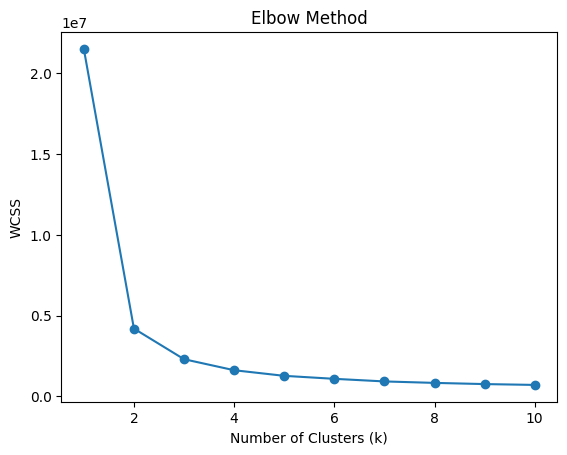

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_svd_100)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

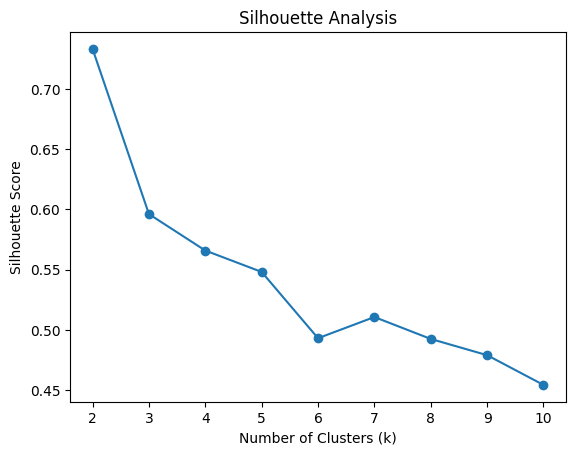

In [ ]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_svd_100)
    score = silhouette_score(X_svd_100, labels)
    scores.append(score)

import matplotlib.pyplot as plt

plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [ ]:
print(scores)

[np.float64(0.7330711484901368), np.float64(0.5960922316046204), np.float64(0.5658573453284308), np.float64(0.5481023965550654), np.float64(0.49313177500074484), np.float64(0.5107069909974038), np.float64(0.49252466805152484), np.float64(0.4790635066627029), np.float64(0.45439645386588406)]


In [ ]:
from sklearn.cluster import KMeans

# K = 2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
Netflix_Clustering['Cluster_k2'] = kmeans_2.fit_predict(X_svd_100)

# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
Netflix_Clustering['Cluster_k3'] = kmeans_3.fit_predict(X_svd_100)

# K = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
Netflix_Clustering['Cluster_k4'] = kmeans_4.fit_predict(X_svd_100)

In [ ]:
print("K=2 Cluster Counts:")
print(Netflix_Clustering['Cluster_k2'].value_counts())

print("\nK=3 Cluster Counts:")
print(Netflix_Clustering['Cluster_k3'].value_counts())

print("\nK=4 Cluster Counts:")
print(Netflix_Clustering['Cluster_k4'].value_counts())

K=2 Cluster Counts:
Cluster_k2
1    5067
0    2710
Name: count, dtype: int64

K=3 Cluster Counts:
Cluster_k3
0    3603
1    2599
2    1575
Name: count, dtype: int64

K=4 Cluster Counts:
Cluster_k4
2    3192
1    2533
0    1087
3     965
Name: count, dtype: int64


In [ ]:
Netflix_Clustering.columns

Index(['release_year', 'year_added', 'month_added', 'movie_duration',
       'tv_show_seasons', 'Anime Features', 'Children & Family Movies',
       'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows',
       'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas',
       'Faith & Spirituality', 'Horror Movies', 'Independent Movies',
       'International Movies', 'International TV Shows', 'Kids' TV',
       'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals', 'Reality TV',
       'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy',
       'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies',
       'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'type_TV Show', 'country_Brazil',
       'co

In [ ]:
Netflix_Clustering.groupby('Cluster_k3').agg({
    'movie_duration':'mean',
    'tv_show_seasons':'mean',
    'release_year':'mean'
})

,movie_duration,tv_show_seasons,release_year
Cluster_k3,,,
0,89.163197,0.00000,2014.008326
1,2.266641,1.62601,2016.070027
2,131.322540,0.00000,2010.248889


In [ ]:
Netflix_Clustering_features = Netflix_Clustering.drop(['Cluster_k2', 'Cluster_k3', 'Cluster_k4'], axis=1, errors = "ignore")

In [ ]:
Netflix_Clustering_features.columns

Index(['release_year', 'year_added', 'month_added', 'movie_duration',
       'tv_show_seasons', 'Anime Features', 'Children & Family Movies',
       'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows',
       'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas',
       'Faith & Spirituality', 'Horror Movies', 'Independent Movies',
       'International Movies', 'International TV Shows', 'Kids' TV',
       'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals', 'Reality TV',
       'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy',
       'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies',
       'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'type_TV Show', 'country_Brazil',
       'co

In [ ]:
cluster_insights = Netflix_Clustering_features.groupby(Netflix_Clustering["Cluster_k3"]).mean().T

In [ ]:
cluster_insights[0].sort_values(ascending=False).head(15)

,0
year_added,2018.382182
release_year,2014.008326
movie_duration,89.163197
month_added,6.598113
country_United States,0.404940
rating_TV-MA,0.398002
International Movies,0.351929
country_Other,0.306134
rating_TV-14,0.182348
Independent Movies,0.137108


In [ ]:
cluster_insights[1].sort_values(ascending=False).head(15)

,1
year_added,2018.503270
release_year,2016.070027
month_added,6.985379
movie_duration,2.266641
tv_show_seasons,1.626010
type_TV Show,0.923432
rating_TV-MA,0.402078
country_United States,0.307426
rating_TV-14,0.261639
TV Dramas,0.246633


In [ ]:
cluster_insights[2].sort_values(ascending=False).head(15)

,2
year_added,2018.731429
release_year,2010.248889
movie_duration,131.322540
month_added,6.876190
International Movies,0.653968
country_India,0.414603
rating_TV-14,0.375238
country_Other,0.269841
rating_TV-MA,0.242540
Dramas,0.233016


#####**Insights for K=4**

In [ ]:
cluster_insights_2 = Netflix_Clustering_features.groupby(Netflix_Clustering["Cluster_k4"]).mean().T

In [ ]:
cluster_insights_2[0].sort_values(ascending=False).head(15)

,0
year_added,2018.689052
release_year,2009.101196
movie_duration,138.869365
month_added,6.970561
International Movies,0.694572
country_India,0.502300
rating_TV-14,0.415823
Dramas,0.257590
country_Other,0.233671
Action & Adventure,0.229071


In [ ]:
cluster_insights_2[1].sort_values(ascending=False).head(15)

,1
year_added,2018.515989
release_year,2016.180813
month_added,6.977102
tv_show_seasons,1.668377
movie_duration,1.247927
type_TV Show,0.947493
rating_TV-MA,0.408212
country_United States,0.300434
rating_TV-14,0.264508
TV Dramas,0.253060


In [ ]:
cluster_insights_2[2].sort_values(ascending=False).head(15)

,2
year_added,2018.550439
release_year,2013.678885
movie_duration,99.084900
month_added,6.573308
International Movies,0.426378
country_United States,0.357143
rating_TV-MA,0.356830
country_Other,0.348058
rating_TV-14,0.207080
rating_R,0.156955


In [ ]:
cluster_insights_2[3].sort_values(ascending=False).head(15)

,3
year_added,2018.024870
release_year,2014.339896
movie_duration,65.894301
month_added,6.762694
country_United States,0.505699
rating_TV-MA,0.456995
International Movies,0.198964
country_Other,0.176166
rating_TV-14,0.150259
rating_TV-PG,0.131606


**Insights:**

By training the above model on the clustering data after applying feature scaling and PCA, the model has divided the data into 2 clusters accurately, but it is clustering the data into 2 clusters we actually know i.e. Movies and TV Show, so the model has performed clustering correclty, but the insights are not at all useful for business decisions. This happened because we applied clustering on all the features in the dataset, which made the algorithm to divide it 2 known clusters. So now we need to drop features like type, movies_duration, TV_show duration etc. and only fed features like genre, rating, release year, country etc into the model.

### ML Model - 2

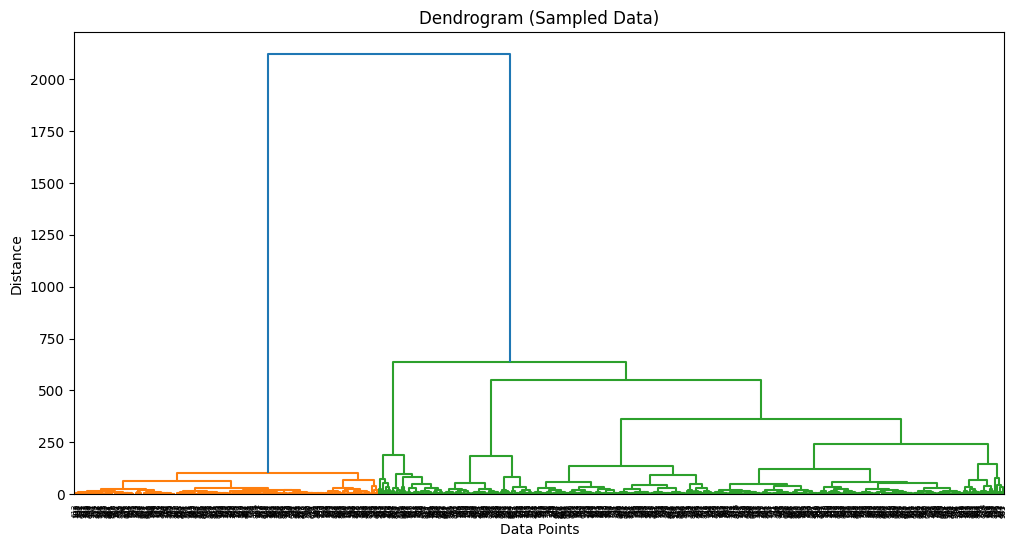

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
linkage_matrix = linkage(X_svd_100, method='ward')
sample_indices = np.random.choice(range(X_svd_100.shape[0]), size=1000, replace=False)
X_sample = X_svd_100[sample_indices]

linkage_sample = linkage(X_sample, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linkage_sample)
plt.title("Dendrogram (Sampled Data)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

From this dendrogram, we can finalize that no. of clusters = 2

In [ ]:
Netflix_Clustering.columns

Index(['release_year', 'year_added', 'month_added', 'movie_duration',
       'tv_show_seasons', 'Anime Features', 'Children & Family Movies',
       'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows',
       'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas',
       'Faith & Spirituality', 'Horror Movies', 'Independent Movies',
       'International Movies', 'International TV Shows', 'Kids' TV',
       'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals', 'Reality TV',
       'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy',
       'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies',
       'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'type_TV Show', 'country_Brazil',
       'co

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

Netflix_Clustering['hc_cluster'] = hc.fit_predict(X_svd_100)

In [ ]:
silhouette_score(X_svd_100, Netflix_Clustering['hc_cluster'])

np.float64(0.7322890921010965)

In [ ]:
Netflix_Clustering['hc_cluster'].value_counts()

,count
hc_cluster,
0,5246
1,2531


In [ ]:
hc_cluster_insights = Netflix_Clustering_features.groupby(Netflix_Clustering["hc_cluster"]).mean().T

In [ ]:
hc_cluster_insights[0].sort_values(ascending=False).head(15)

,0
year_added,2018.481891
release_year,2012.783073
movie_duration,101.176325
month_added,6.691384
International Movies,0.439954
rating_TV-MA,0.348647
country_United States,0.341212
country_Other,0.292604
rating_TV-14,0.240183
country_India,0.162219


In [ ]:
hc_cluster_insights[1].sort_values(ascending=False).head(15)

,1
year_added,2018.517187
release_year,2016.325563
month_added,6.975504
tv_show_seasons,1.668906
movie_duration,1.267483
type_TV Show,0.947452
rating_TV-MA,0.407744
country_United States,0.299881
rating_TV-14,0.263927
TV Dramas,0.253260


## **Experiment 2**:
Dropping the features due to which the algorithm clustered the data into 2 known clusters

In [ ]:
Exp_2N = Netflix_data.copy()

In [ ]:
Exp_2N.head()

,type,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,main_genre
0,TV Show,Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows
1,Movie,Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas
2,Movie,Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies
3,Movie,United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure
4,Movie,United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,Dramas


### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
Exp_2N.isnull().sum()

,0
type,0
country,507
date_added,10
release_year,0
rating,7
duration,0
listed_in,0
description,0
year_added,10
month_added,10


In [ ]:
Exp_2N['country'].fillna('Unknown', inplace=True)
Exp_2N['rating'].fillna('Not Rated', inplace=True)

/tmp/ipykernel_7684/1664196493.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_7684/1664196493.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

In [ ]:
Exp_2N.dropna(
    subset=['date_added', 'year_added', 'month_added'],
    inplace=True
)
Exp_2N['country'].fillna('Unknown', inplace=True)
Exp_2N['rating'].fillna('Not Rated', inplace=True)

/tmp/ipykernel_7684/836904566.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_7684/836904566.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

In [ ]:
Exp_2N.drop('date_added', axis = 1, inplace = True)
# We have already extracted information from it in the form of year_added & mobth_added columns so we don't need this feature/column for training our algorithm

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
Exp_2N.head()

,type,country,release_year,rating,duration,listed_in,description,year_added,month_added,main_genre
0,TV Show,Brazil,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows
1,Movie,Mexico,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas
2,Movie,Singapore,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies
3,Movie,United States,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure
4,Movie,United States,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,Dramas


Although features such as type and duration may help separate content into structurally distinct groups, they primarily capture obvious format-level differences such as Movies vs TV Shows. Since the goal of this project was to uncover deeper content-based and business-relevant segmentation, these features were removed to reduce dominance of known distinctions and allow clustering to focus on richer metadata such as genres, ratings, countries, and release patterns.

In [ ]:
#Now we need to drop columns like type, duration so that clustring would not lead to 2 clusters
Exp_2N.drop(['type', 'duration'], axis=1, inplace=True)

In [ ]:
#Dropping not required columns
Exp_2N.drop(['description', 'main_genre'], axis = 1, inplace = True)

In [ ]:
# Encode your categorical columns
Exp_2N['listed_in'] = Exp_2N['listed_in'].apply(lambda x: x.split(','))

In [ ]:
Exp_2N.head()

,country,release_year,rating,listed_in,year_added,month_added
0,Brazil,2020,TV-MA,"[International TV Shows, TV Dramas, TV Sci-F...",2020.0,8.0
1,Mexico,2016,TV-MA,"[Dramas, International Movies]",2016.0,12.0
2,Singapore,2011,R,"[Horror Movies, International Movies]",2018.0,12.0
3,United States,2009,PG-13,"[Action & Adventure, Independent Movies, Sci...",2017.0,11.0
4,United States,2008,PG-13,[Dramas],2020.0,1.0


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_df = pd.DataFrame(
    mlb.fit_transform(Exp_2N['listed_in']),
    columns=mlb.classes_,
    index=Exp_2N.index
)

Exp_2N = pd.concat([Exp_2N, genre_df], axis=1)

KeyError: 'listed_in'

In [ ]:
Exp_2N.head()

,country,release_year,rating,listed_in,year_added,month_added,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
0,Brazil,2020,TV-MA,"[International TV Shows, TV Dramas, TV Sci-F...",2020.0,8.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Mexico,2016,TV-MA,"[Dramas, International Movies]",2016.0,12.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Singapore,2011,R,"[Horror Movies, International Movies]",2018.0,12.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,United States,2009,PG-13,"[Action & Adventure, Independent Movies, Sci...",2017.0,11.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,United States,2008,PG-13,[Dramas],2020.0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#We are performing this step because, when we applied encoding the feature size was around 774 features, even after applying pca the feature size was 702.
#So we need to select only top 10-15 countries so that feature size will not increase
top_countries = Exp_2N['country'].value_counts().head(15).index
Exp_2N['country'] = Exp_2N['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

In [ ]:
Exp_2N = pd.get_dummies(Exp_2N, columns=['country','rating'], drop_first=True)

In [ ]:
Exp_2N.shape

(7777, 106)

In [ ]:
Exp_2N.columns.to_list()

['release_year',
 'listed_in',
 'year_added',
 'month_added',
 ' Anime Features',
 ' Children & Family Movies',
 ' Classic & Cult TV',
 ' Classic Movies',
 ' Comedies',
 ' Crime TV Shows',
 ' Cult Movies',
 ' Documentaries',
 ' Docuseries',
 ' Dramas',
 ' Faith & Spirituality',
 ' Horror Movies',
 ' Independent Movies',
 ' International Movies',
 ' International TV Shows',
 " Kids' TV",
 ' Korean TV Shows',
 ' LGBTQ Movies',
 ' Music & Musicals',
 ' Reality TV',
 ' Romantic Movies',
 ' Romantic TV Shows',
 ' Sci-Fi & Fantasy',
 ' Science & Nature TV',
 ' Spanish-Language TV Shows',
 ' Sports Movies',
 ' Stand-Up Comedy',
 ' Stand-Up Comedy & Talk Shows',
 ' TV Action & Adventure',
 ' TV Comedies',
 ' TV Dramas',
 ' TV Horror',
 ' TV Mysteries',
 ' TV Sci-Fi & Fantasy',
 ' TV Thrillers',
 ' Teen TV Shows',
 ' Thrillers',
 'Action & Adventure',
 'Anime Features',
 'Anime Series',
 'British TV Shows',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Movies',
 'Comedies',
 'Cri

In [ ]:
#Columns names are getting duplicated
Exp_2N.columns = Exp_2N.columns.str.strip()

In [ ]:
Exp_2N = Exp_2N.loc[:,~Exp_2N.columns.duplicated()]

In [ ]:
Exp_2N.shape

(7777, 75)

In [ ]:
Exp_2N.columns.to_list()

['release_year',
 'listed_in',
 'year_added',
 'month_added',
 'Anime Features',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Movies',
 'Comedies',
 'Crime TV Shows',
 'Cult Movies',
 'Documentaries',
 'Docuseries',
 'Dramas',
 'Faith & Spirituality',
 'Horror Movies',
 'Independent Movies',
 'International Movies',
 'International TV Shows',
 "Kids' TV",
 'Korean TV Shows',
 'LGBTQ Movies',
 'Music & Musicals',
 'Reality TV',
 'Romantic Movies',
 'Romantic TV Shows',
 'Sci-Fi & Fantasy',
 'Science & Nature TV',
 'Spanish-Language TV Shows',
 'Sports Movies',
 'Stand-Up Comedy',
 'Stand-Up Comedy & Talk Shows',
 'TV Action & Adventure',
 'TV Comedies',
 'TV Dramas',
 'TV Horror',
 'TV Mysteries',
 'TV Sci-Fi & Fantasy',
 'TV Thrillers',
 'Teen TV Shows',
 'Thrillers',
 'Action & Adventure',
 'Anime Series',
 'British TV Shows',
 'Movies',
 'TV Shows',
 'country_Brazil',
 'country_Canada',
 'country_Egypt',
 'country_France',
 'country_India',
 'country_Japan',
 'country

In [ ]:
Exp_2N.drop('listed_in', axis=1, inplace=True)

In [ ]:
Exp_2N.shape

(7777, 74)

In [ ]:
Exp_2N.columns

Index(['release_year', 'year_added', 'month_added', 'Anime Features',
       'Children & Family Movies', 'Classic & Cult TV', 'Classic Movies',
       'Comedies', 'Crime TV Shows', 'Cult Movies', 'Documentaries',
       'Docuseries', 'Dramas', 'Faith & Spirituality', 'Horror Movies',
       'Independent Movies', 'International Movies', 'International TV Shows',
       'Kids' TV', 'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals',
       'Reality TV', 'Romantic Movies', 'Romantic TV Shows',
       'Sci-Fi & Fantasy', 'Science & Nature TV', 'Spanish-Language TV Shows',
       'Sports Movies', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'country_Brazil', 'country_Canada',
       'country_Egypt', 'country_France', 'country_I

In [ ]:
Exp_2N.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7777 entries, 0 to 7786
Data columns (total 74 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   release_year                  7777 non-null   int64  
 1   year_added                    7777 non-null   float64
 2   month_added                   7777 non-null   float64
 3   Anime Features                7777 non-null   int64  
 4   Children & Family Movies      7777 non-null   int64  
 5   Classic & Cult TV             7777 non-null   int64  
 6   Classic Movies                7777 non-null   int64  
 7   Comedies                      7777 non-null   int64  
 8   Crime TV Shows                7777 non-null   int64  
 9   Cult Movies                   7777 non-null   int64  
 10  Documentaries                 7777 non-null   int64  
 11  Docuseries                    7777 non-null   int64  
 12  Dramas                        7777 non-null   int64  
 13  Faith & 

**“Although scaling is generally recommended for numerical features, in this case it degraded clustering performance due to the dominance of high-dimensional NLP features. Therefore, I retained the original feature scale to preserve meaningful distance relationships.”**

In [ ]:
# #Applying scaling on numeric columns
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# num_cols = ['release_year', 'year_added', 'month_added']

# scaler = StandardScaler()
# Exp_2N[num_cols] = scaler.fit_transform(Exp_2N[num_cols])


In [ ]:
Exp_2N.dtypes.value_counts()

,count
int64,43
bool,29
float64,2


In [ ]:
non_numeric_cols = Exp_2N.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

Non-numeric columns: []


In [ ]:
Exp_2N = Exp_2N.apply(pd.to_numeric)

In [ ]:
Exp_2N = Exp_2N.astype(int)

In [ ]:
Exp_2N.head()

,release_year,year_added,month_added,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,2020,2020,8,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,2016,2016,12,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2011,2018,12,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,2009,2017,11,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2008,2020,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
Exp_2N.shape

(7777, 74)

In [ ]:
Exp_2N.dtypes.value_counts()

,count
int64,74


In [ ]:
from scipy.sparse import csr_matrix, hstack
#convert to sparse matrix
structured_matrix_2 = csr_matrix(Exp_2N.values)
print("Structured matrix shape:", structured_matrix_2.shape)

Structured matrix shape: (7777, 74)


In [ ]:
# Step 6: Combine with NLP matrices
final_feature_matrix_2 = hstack([
    structured_matrix_2,
    description_matrix,
    title_matrix,
    cast_matrix,
    director_matrix
])

print("Final combined feature matrix shape:", final_feature_matrix_2.shape)

Final combined feature matrix shape: (7777, 2524)


### 7. Dimensionality Reduction

#####**We are going to use TruncatedSVD for Dimensionality Reduction as we have matrix of features**

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd_2 = TruncatedSVD(n_components=100, random_state=42)
X_svd_100_2= svd_2.fit_transform(final_feature_matrix_2)

print("SVD matrix shape:", X_svd_100_2.shape)

SVD matrix shape: (7777, 100)


In [ ]:
svd_50_2 = TruncatedSVD(n_components=50, random_state=42)
X_svd_50_2 = svd_50_2.fit_transform(final_feature_matrix_2)
print("SVD matrix shape:", X_svd_50_2.shape)

SVD matrix shape: (7777, 50)


In [ ]:
svd_150_2 = TruncatedSVD(n_components=150, random_state=42)
X_svd_150_2 = svd_150_2.fit_transform(final_feature_matrix_2)
print("SVD matrix shape:", X_svd_150_2.shape)

SVD matrix shape: (7777, 150)


In [ ]:
print("Explained Variance:", svd_2.explained_variance_ratio_.sum())

Explained Variance: 0.9512498336009385


In [ ]:
print("Explained Variance:", svd_50_2.explained_variance_ratio_.sum())

Explained Variance: 0.9411261950185806


In [ ]:
print("Explained Variance:", svd_150_2.explained_variance_ratio_.sum())

Explained Variance: 0.9581831995527516


##### Do you think that dimensionality reduction is needed? Explain Why?

After applying encoding the shape of the dataset is - 7777 X 108. It will be difficult for clustering algorithms to handle these many features so we have to apply dimensionality reduction.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

## Feature scaling

In [ ]:
X_scaledN = scaler.fit_transform(Exp_2N)

## Principal Component Analysis

In [ ]:
pcan = PCA(n_components=0.95)
X_pcaN = pcan.fit_transform(X_scaledN)

In [ ]:
X_pcaN.shape

In [ ]:
pcan.explained_variance_ratio_

In [ ]:
sum(pcan.explained_variance_ratio_)

In [ ]:
plt.plot(np.cumsum(pcan.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

## ML Model - 1

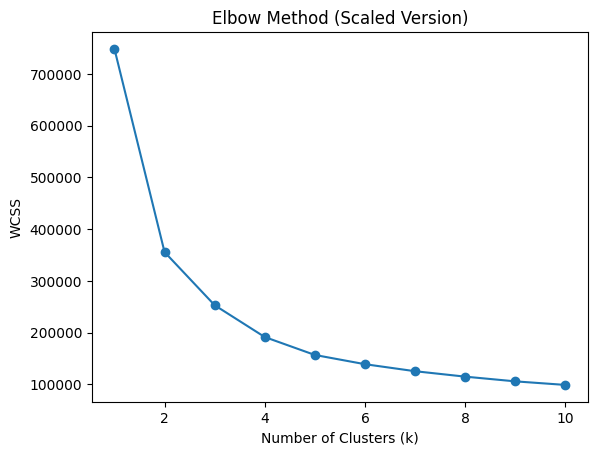

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_svd_100_2)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method (Scaled Version)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

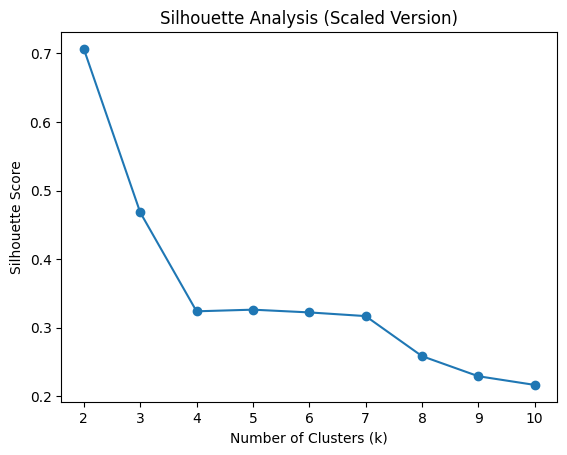

In [ ]:
from sklearn.metrics import silhouette_score

scores1 = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd_100_2)
    score = silhouette_score(X_svd_100_2, labels)
    scores1.append(score)

plt.plot(range(2, 11), scores1, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (Scaled Version)")
plt.show()

In [ ]:
print(scores1)

[np.float64(0.706501048535263), np.float64(0.46824002972714623), np.float64(0.3239124609557251), np.float64(0.3263024294132102), np.float64(0.3223010403443552), np.float64(0.31693327536363086), np.float64(0.25853450639972), np.float64(0.22922556069412836), np.float64(0.2165737523045899)]


In [ ]:
from sklearn.cluster import KMeans

# k = 2
kmeans_2_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2_2 = kmeans_2_2.fit_predict(X_svd_100_2)

# k = 3
kmeans_3_2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3_2 = kmeans_3_2.fit_predict(X_svd_100_2)

# k = 4
kmeans_4_2 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4_2 = kmeans_4_2.fit_predict(X_svd_100_2)

In [ ]:
Exp_2N['Cluster_k2'] = labels_2_2
Exp_2N['Cluster_k3'] = labels_3_2
Exp_2N['Cluster_k4'] = labels_4_2

In [ ]:
print("K=2:\n", Netflix_Clustering['Cluster_k2'].value_counts())
print("\nK=3:\n", Netflix_Clustering['Cluster_k3'].value_counts())
print("\nK=4:\n", Netflix_Clustering['Cluster_k4'].value_counts())

K=2:
 Cluster_k2
1    5067
0    2710
Name: count, dtype: int64

K=3:
 Cluster_k3
0    3603
1    2599
2    1575
Name: count, dtype: int64

K=4:
 Cluster_k4
2    3192
1    2533
0    1087
3     965
Name: count, dtype: int64


In [ ]:
Exp_2N_features = Exp_2N.drop(['Cluster_k2', 'Cluster_k3', 'Cluster_k4'], axis=1, errors = "ignore")

In [ ]:
cluster_insights_n = Exp_2N_features.groupby(Exp_2N["Cluster_k3"]).mean().T

In [ ]:
cluster_insights_n[0].sort_values(ascending=False).head(15)

,0
year_added,2018.570743
release_year,2005.590727
month_added,6.483613
International Movies,0.341327
country_United States,0.338129
country_Other,0.269384
rating_TV-14,0.265388
country_India,0.201439
Action & Adventure,0.172662
rating_R,0.161471


In [ ]:
cluster_insights_n[1].sort_values(ascending=False).head(15)

,1
year_added,2018.486512
release_year,2017.115722
month_added,6.804310
rating_TV-MA,0.420750
country_United States,0.321788
International Movies,0.286832
country_Other,0.260335
rating_TV-14,0.240543
rating_TV-PG,0.102634
country_India,0.099282


In [ ]:
cluster_insights_n[2].sort_values(ascending=False).head(15)

,2
year_added,2018.287356
release_year,1977.609195
month_added,7.731801
country_United States,0.421456
International Movies,0.379310
rating_TV-14,0.340996
Dramas,0.283525
country_Other,0.260536
Action & Adventure,0.237548
country_India,0.187739


Cluster Insights for K=4

In [ ]:
cluster_insights_n_2 = Exp_2N_features.groupby(Exp_2N["Cluster_k4"]).mean().T

In [ ]:
cluster_insights_n_2[0].sort_values(ascending=False).head(15)

,0
year_added,2018.350902
release_year,2016.894586
month_added,9.683758
rating_TV-MA,0.390719
country_United States,0.320252
International Movies,0.282727
country_Other,0.268977
rating_TV-14,0.246921
rating_TV-PG,0.111429
country_India,0.107706


In [ ]:
cluster_insights_n_2[1].sort_values(ascending=False).head(15)

,1
year_added,2018.331967
release_year,1976.676230
month_added,7.737705
country_United States,0.413934
International Movies,0.393443
rating_TV-14,0.356557
Dramas,0.295082
country_Other,0.262295
Action & Adventure,0.250000
country_India,0.200820


In [ ]:
cluster_insights_n_2[2].sort_values(ascending=False).head(15)

,2
year_added,2018.643285
release_year,2016.874003
month_added,3.444149
rating_TV-MA,0.434840
country_United States,0.322473
International Movies,0.291888
country_Other,0.252992
rating_TV-14,0.236037
Independent Movies,0.101729
country_India,0.095412


In [ ]:
cluster_insights_n_2[3].sort_values(ascending=False).head(15)

,3
year_added,2018.576402
release_year,2004.192456
month_added,6.483559
International Movies,0.350097
country_United States,0.348162
country_Other,0.263056
rating_TV-14,0.260155
country_India,0.204062
Action & Adventure,0.177950
rating_R,0.170213


In [ ]:
cluster_summary = Exp_2N.groupby('Cluster_k4').mean()

In [ ]:
cluster_summary.T.sort_values(by=0, ascending=False).head(10)

Cluster_k4,0,1,2,3
year_added,2018.350902,2018.331967,2018.643285,2018.576402
release_year,2016.894586,1976.676230,2016.874003,2004.192456
month_added,9.683758,7.737705,3.444149,6.483559
Cluster_k3,0.965339,2.000000,0.962434,0.032882
rating_TV-MA,0.390719,0.127049,0.434840,0.152805
country_United States,0.320252,0.413934,0.322473,0.348162
International Movies,0.282727,0.393443,0.291888,0.350097
country_Other,0.268977,0.262295,0.252992,0.263056
rating_TV-14,0.246921,0.356557,0.236037,0.260155
rating_TV-PG,0.111429,0.155738,0.094415,0.089942


**Insights:**

Clustering helped segment Netflix content into distinct categories such as TV series, international movies, family-friendly films, and mature Hollywood movies. These clusters can help Netflix improve recommendation systems, guide content acquisition strategies, optimize marketing campaigns, and better personalize user experiences.

## ML Model - 2

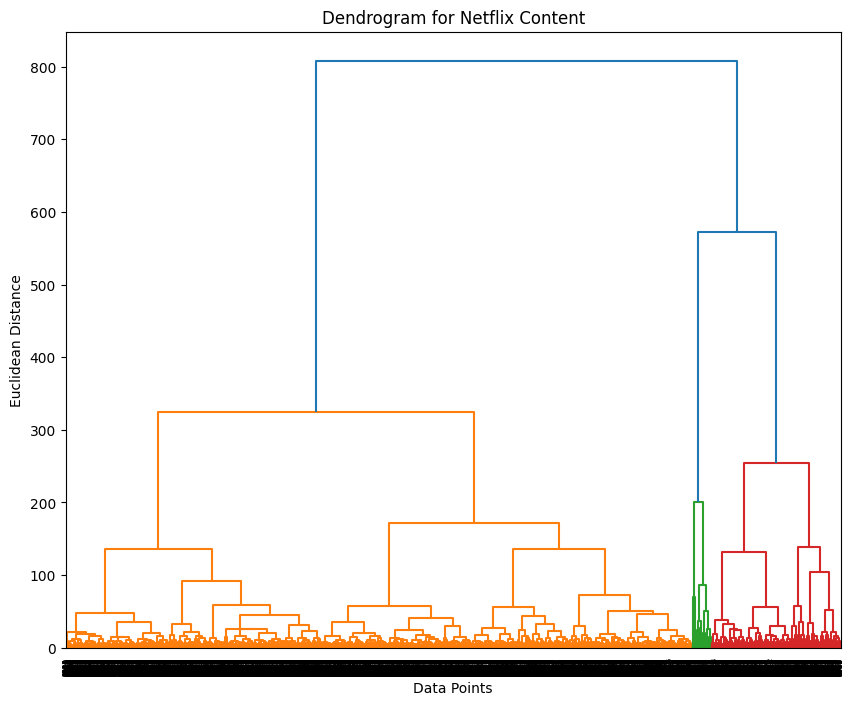

In [ ]:
# ML Model - 2 Implementation
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,8))  # MUST come first

dendrogram = sch.dendrogram(
    sch.linkage(X_svd_100_2, method='ward')
)

plt.title('Dendrogram for Netflix Content')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')

plt.show()
# Fit the Algorithm

# Predict on the model

From this dendrogram, we can finalize that no. of clusters = 3

In [ ]:
#Model Implementation
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    metric = 'euclidean',
    linkage='ward'
)

Exp_2N['hc_cluster'] = hc.fit_predict(X_svd_100_2)

In [ ]:
silhouette_score(X_svd_100_2, Exp_2N['hc_cluster'])

np.float64(0.48370278961392665)

In [ ]:
Exp_2N['hc_cluster'].value_counts()

,count
hc_cluster,
0,6292
1,1292
2,193


In [ ]:
cluster_understanding = Exp_2N_features.groupby(Exp_2N['hc_cluster']).mean().T

In [ ]:
cluster_understanding[0].sort_values(ascending=False).head(15)

,0
year_added,2018.475366
release_year,2017.080579
month_added,6.804514
rating_TV-MA,0.419580
country_United States,0.320089
International Movies,0.285760
country_Other,0.260648
rating_TV-14,0.242689
rating_TV-PG,0.103306
country_India,0.099332


In [ ]:
cluster_understanding[1].sort_values(ascending=False).head(15)

,1
year_added,2018.551084
release_year,2004.668731
month_added,6.569659
country_United States,0.360681
International Movies,0.340557
country_Other,0.264706
rating_TV-14,0.255418
country_India,0.197368
Action & Adventure,0.181889
rating_R,0.167183


In [ ]:
cluster_understanding[2].sort_values(ascending=False).head(15)

,2
year_added,2018.694301
release_year,1973.455959
month_added,7.544041
International Movies,0.440415
rating_TV-14,0.367876
country_United States,0.357513
Dramas,0.321244
country_Other,0.279793
Action & Adventure,0.259067
country_India,0.222798


“Hierarchical clustering suggested k=3 based on the dendrogram. However, the resulting clusters were highly imbalanced, with one dominant cluster containing most data points. In contrast, K-Means with k=4 produced more balanced and interpretable clusters, so it was selected as the final model.”

In [ ]:
import pickle
with open('kmeans_model.pkl', 'wb') as f:
  pickle.dump(kmeans_4_2, f)

In [ ]:
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_2, f)

In [ ]:
pickle.dump(description_vectorizer, open('desc_vectorizer.pkl', 'wb'))
pickle.dump(title_vectorizer, open('title_vectorizer.pkl', 'wb'))
pickle.dump(cast_vectorizer, open('cast_vectorizer.pkl', 'wb'))
pickle.dump(director_vectorizer, open('director_vectorizer.pkl', 'wb'))

## Final dataset

In [ ]:
Netflix_final_df = Netflix_df.copy()

In [ ]:
Netflix_final_df.shape

In [ ]:
Netflix_final_df.columns

In [ ]:
Netflix_final_df.isnull().sum()

In [ ]:
Netflix_final_df['country'].fillna('Unknown', inplace=True)
Netflix_final_df['rating'].fillna('Not Rated', inplace=True)

In [ ]:
Netflix_final_df.dropna(
    subset=['date_added'],
    inplace=True
)

In [ ]:
Netflix_final_df.shape

In [ ]:
Netflix_final_df.drop(['show_id', 'director', 'cast'], axis=1, inplace=True)

In [ ]:
Netflix_final_df.info()

In [ ]:
Netflix_final_df['date_added'] = Netflix_final_df['date_added'].str.strip()
Netflix_final_df['date_added'] = pd.to_datetime(Netflix_final_df['date_added'])

In [ ]:
Netflix_final_df.info()

In [ ]:
Netflix_final_df.shape

In [ ]:
Exp_2N.shape

In [ ]:
print(Netflix_final_df.index.equals(Exp_2N.index))

In [ ]:
Netflix_final_df['kmeans_cluster'] = Exp_2N['Kmeans20_clusters'].values
Netflix_final_df['Hierarchical_cluster'] = Exp_2N['hc_cluster'].values

In [ ]:
Netflix_final_df.info()

In [ ]:
Netflix_final_df.head(20)

Checking whether the cluster labels are assigned accurately.

In [ ]:
print(Exp_2N['Kmeans20_clusters'].value_counts().sort_index())
print(Netflix_final_df['kmeans_cluster'].value_counts().sort_index())

In [ ]:
print(Exp_2N['hc_cluster'].value_counts().sort_index())
print(Netflix_final_df['Hierarchical_cluster'].value_counts().sort_index())

In [ ]:
for col in ['listed_in', 'country', 'rating', 'type']:
    print(f"\nTop values for {col}:")
    print(Netflix_final_df.groupby('kmeans_cluster')[col].value_counts().groupby(level=0).head(5))

After mapping the final K-Means cluster labels back to the readable cleaned Netflix dataset, validation was performed using row-count checks, index alignment, cluster-count consistency, manual row inspection, and cluster-wise summary profiling. The assigned labels remained fully consistent with the transformed modeling dataset, confirming correct label transfer.

In [ ]:
cluster_name_map = {
    0: "Global TV Content",
    1: "International Movies",
    2: "Family & Light Entertainment Movies",
    3: "Mature Hollywood & Independent Cinema"
}
Netflix_final_df["cluster_name"] = Netflix_final_df["kmeans_cluster"].map(cluster_name_map)

In [ ]:
Netflix_final_df[["kmeans_cluster", "cluster_name"]].head()

In [ ]:
import re

def clean_title(text):
    text = str(text)
    text = text.replace("â", "")
    text = re.sub(r'[\u200b-\u200d\uFEFF]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Netflix_final_df["title_original"] = Netflix_final_df["title"]
Netflix_final_df["title"] = Netflix_final_df["title"].apply(clean_title)

In [ ]:
Netflix_final_df[["title_original", "title"]].head(50)

In [ ]:
import re

def clean_title(text):
    text = str(text)

    # Try to fix mojibake encoding
    try:
        text = text.encode("latin1").decode("utf-8")
    except:
        pass

    # Remove specific junk if still present
    text = text.replace("â", "")

    # Remove invisible unicode chars
    text = re.sub(r'[\u200b-\u200d\uFEFF]', '', text)

    # Clean extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

Netflix_final_df["title_original"] = Netflix_final_df["title"]
Netflix_final_df["title"] = Netflix_final_df["title"].apply(clean_title)

In [ ]:
Netflix_final_df[["title_original", "title"]].head(50)

In [ ]:
Netflix_final_df.drop(["title_original"], axis = 1, inplace = True)

In [ ]:
Netflix_final_df.to_csv("netflix_clustered_final.csv", index=False)

In [ ]:
new_df = pd.read_csv('/content/netflix_clustered_final.csv')

In [ ]:
new_df.columns

###This clustering project succesfully segmented Netflix content into distinct groups or clusters.

***Cluster 0: Global TV Content*** -     3504

***Cluster 1: International Movies*** - 2442

***Cluster 2: Family & Light Entertainment Movies*** - 550

***Cluster 3: Mature Hollywood & Independent Cinema*** - 1281

###**Advanced Insights**
**1️⃣ Advanced Insight 1 – Netflix Has Two Dominant Content Types**

Your clusters show a clear separation between:

TV Series Content
Movie Content

Cluster 0 mainly contains:

TV Dramas
TV Comedies
Romantic TV Shows
TV-MA / TV-14 ratings

This suggests that the catalog contains a large concentration of serialized TV content.

Business Insight

Netflix has invested heavily in original TV series, which keeps users engaged longer compared to movies.

Actionable Step

Netflix should continue investing in:

high-quality TV series
especially drama and comedy series

because they drive longer watch sessions and binge-watching.

**2️⃣ Advanced Insight 2 – Strong International Content Presence**

Cluster 1 shows extremely high values for:

International Movies
Indian content
multiple non-US countries

This means a large part of the catalog is global content rather than only Hollywood movies.

Business Insight

Netflix is successfully expanding into regional markets.

International content increases:

global subscribers
regional engagement
Actionable Step

Netflix should:

continue producing regional originals
expand Indian, Korean, and European productions

because international audiences drive subscriber growth.

**3️⃣ Advanced Insight 3 – Distinct Audience Segments (Kids vs Adults)**

Your clusters show two different audience types:

Family / Kids cluster

PG ratings
Comedy movies
Family content

Adult content cluster

R ratings
TV-MA ratings
Thrillers and action movies
Business Insight

The platform serves multiple audience groups with different preferences.

This segmentation is useful for:

recommendation engines
marketing strategies
Actionable Step

Netflix can personalize:

kids profiles → family movies and animation
adult profiles → thrillers, dramas, mature content

This improves user experience and retention.

###**Key Business Insights and Recommendations**

Based on clustering analysis of the Netflix dataset, the following insights were identified:

**1. Strengthen TV Series Production**

The clustering results show that a large portion of the catalog consists of TV dramas and comedy series.

Recommendation:
Netflix should continue investing in original TV series, as serialized content encourages binge-watching and increases platform engagement.

**2. Expand International Content Strategy**

A significant cluster of the dataset contains international movies, especially from countries such as India and other non-US regions.

Recommendation:
Netflix should expand its regional content strategy by producing more localized films and series for international audiences.

**3. Target Different Audience Segments**

The clusters clearly separate family-friendly content from mature adult content.

Recommendation:
Netflix can use these segments to improve personalized recommendations and targeted marketing campaigns.

**4. Improve Recommendation Systems**

Cluster segmentation groups similar titles together based on genre, rating, and production country.

Recommendation:
Netflix can use these clusters to enhance recommendation algorithms by suggesting content from similar clusters that match user viewing patterns.

**5. Optimize Content Acquisition Strategy**

Understanding the composition of content clusters helps identify over-represented or under-represented categories.

Recommendation:
Netflix can balance its catalog by acquiring more content from underrepresented segments to maintain a diverse library.

###**Conclusion:**
This clustering analysis successfully segmented Netflix content into distinct groups such as TV series, international films, family comedies, and mature Hollywood movies. These insights can help streaming platforms better understand their content library, improve recommendation systems, and guide strategic decisions for content acquisition and production.

“I experimented with feature scaling for numeric variables, but it significantly reduced clustering quality as measured by silhouette scores. This is likely because scaling reduced the relative importance of structured features, allowing high-dimensional NLP features to dominate distance calculations. Therefore, I retained the non-scaled feature space for better cluster separation and interpretability.”